#### load the data

In [31]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Load Seeds dataset
seeds = fetch_openml(name='seeds', version=1, as_frame=True)
X = seeds.data
y = seeds.target



In [32]:
seeds

{'data':         V1     V2      V3     V4     V5     V6     V7
 0    15.26  14.84  0.8710  5.763  3.312  2.221  5.220
 1    14.88  14.57  0.8811  5.554  3.333  1.018  4.956
 2    14.29  14.09  0.9050  5.291  3.337  2.699  4.825
 3    13.84  13.94  0.8955  5.324  3.379  2.259  4.805
 4    16.14  14.99  0.9034  5.658  3.562  1.355  5.175
 ..     ...    ...     ...    ...    ...    ...    ...
 205  12.19  13.20  0.8783  5.137  2.981  3.631  4.870
 206  11.23  12.88  0.8511  5.140  2.795  4.325  5.003
 207  13.20  13.66  0.8883  5.236  3.232  8.315  5.056
 208  11.84  13.21  0.8521  5.175  2.836  3.598  5.044
 209  12.30  13.34  0.8684  5.243  2.974  5.637  5.063
 
 [210 rows x 7 columns],
 'target': 0      1
 1      1
 2      1
 3      1
 4      1
       ..
 205    3
 206    3
 207    3
 208    3
 209    3
 Name: Class, Length: 210, dtype: category
 Categories (3, object): ['1', '2', '3'],
 'frame':         V1     V2      V3     V4     V5     V6     V7 Class
 0    15.26  14.84  0.8710  5.

In [16]:
from sklearn.preprocessing import StandardScaler
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.cluster import KMeans
# Compute SSE for k = 1 to 10
sse = []
K = range(1, 21)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

In [21]:
# Print SSE values
for i, val in enumerate(sse, start=1):
    print(f"k = {i}, SSE = {val:.2f}")

k = 1, SSE = 1470.00
k = 2, SSE = 659.94
k = 3, SSE = 430.82
k = 4, SSE = 371.65
k = 5, SSE = 336.24
k = 6, SSE = 296.33
k = 7, SSE = 264.91
k = 8, SSE = 241.93
k = 9, SSE = 226.91
k = 10, SSE = 210.71
k = 11, SSE = 196.21
k = 12, SSE = 189.10
k = 13, SSE = 183.20
k = 14, SSE = 174.50
k = 15, SSE = 165.02
k = 16, SSE = 151.15
k = 17, SSE = 146.19
k = 18, SSE = 139.99
k = 19, SSE = 136.74
k = 20, SSE = 129.41


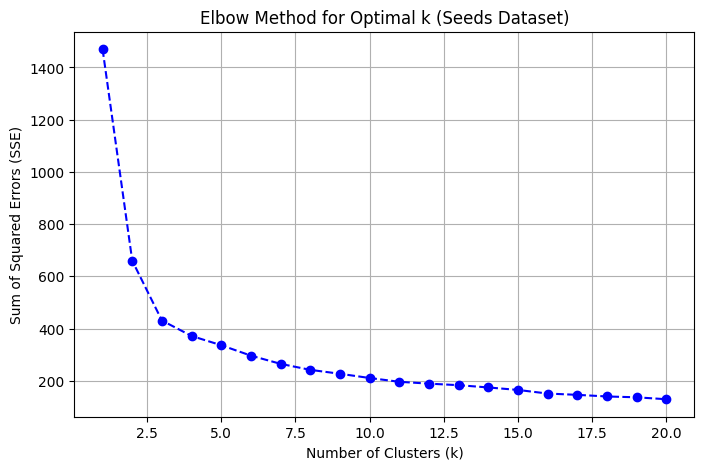

In [22]:
# Plot SSE vs. k
plt.figure(figsize=(8, 5))
plt.plot(K, sse, marker='o', linestyle='--', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k (Seeds Dataset)')
plt.grid(True)
plt.show()